# TD-FALE-GAN: Smart Laboratory Security System — Live Demo

This notebook demonstrates the actual trained models from this repository,
running live: low-light enhancement (TD-FALE-GAN), face detection
(fine-tuned YOLOv8), face recognition (ArcFace), and the ablation study
results.

**Run this notebook from the repository root** (paths below are relative
to it). All sample images used here are real DARK FACE / LFW images
bundled in `notebook_demo_data/` specifically so this notebook is
self-contained and doesn't require downloading the full datasets.

## Setup

If running on a fresh environment (e.g. Google Colab) rather than the
machine this was developed on, uncomment and run the pip install line
below first. On the original machine, everything is already installed.

In [1]:
# !pip install ultralytics insightface onnxruntime opencv-python numpy pandas matplotlib torch

import sys
from pathlib import Path

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "gan"))
sys.path.insert(0, str(ROOT / "data"))

import cv2
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib import image as mpimg

print("Repository root:", ROOT)
print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())

Repository root: C:\Users\ASUS\lab_security_real
Torch: 2.13.0+cpu | CUDA available: False


## 1. Low-Light Enhancement — TD-FALE-GAN

Loads the actual trained generator (`gan/checkpoints/fale_generator.pt`)
and runs it on a real DARK FACE nighttime image, at native resolution
(the generator is fully convolutional).

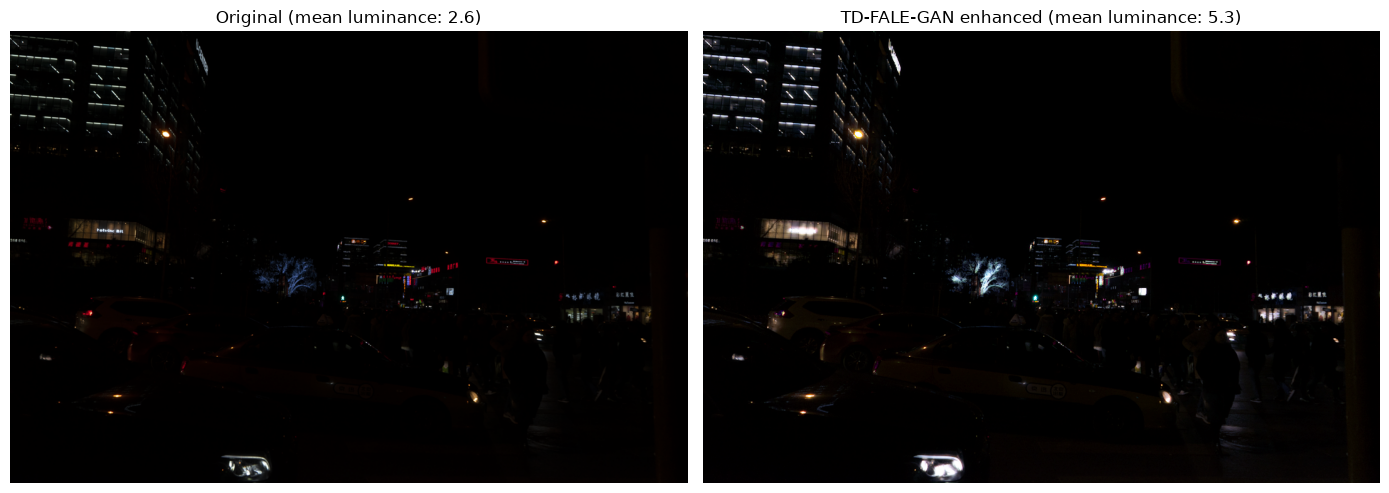

In [2]:
from model import FALEGenerator
from face_utils import face_attention_mask, illumination_map

G = FALEGenerator()
G.load_state_dict(torch.load(ROOT / "gan" / "checkpoints" / "fale_generator.pt", map_location="cpu"))
G.eval()

sample_img_path = ROOT / "notebook_demo_data" / "darkface_samples" / "1004.png"
img_bgr = cv2.imread(str(sample_img_path))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w = img_rgb.shape[:2]

mask = face_attention_mask((h, w), [], 1.0, 1.0)  # no box prior, matches deployment inference
img_t = torch.from_numpy(img_rgb.astype(np.float32) / 255.0).permute(2, 0, 1).unsqueeze(0)
mask_t = torch.from_numpy(mask).unsqueeze(0).unsqueeze(0)
illum_t = illumination_map(img_t)

with torch.no_grad():
    enhanced, _ = G(img_t, mask_t, illum_t)
enhanced_rgb = (enhanced[0].permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(img_rgb); axes[0].set_title(f"Original (mean luminance: {img_rgb.mean():.1f})"); axes[0].axis("off")
axes[1].imshow(enhanced_rgb); axes[1].set_title(f"TD-FALE-GAN enhanced (mean luminance: {enhanced_rgb.mean():.1f})"); axes[1].axis("off")
plt.tight_layout()
plt.show()

## 2. Face Detection — Fine-Tuned YOLOv8

Loads the detector fine-tuned on DARK FACE (`finetune/runs/face_finetune_v3/weights/best.pt`)
and runs it live on real nighttime images.

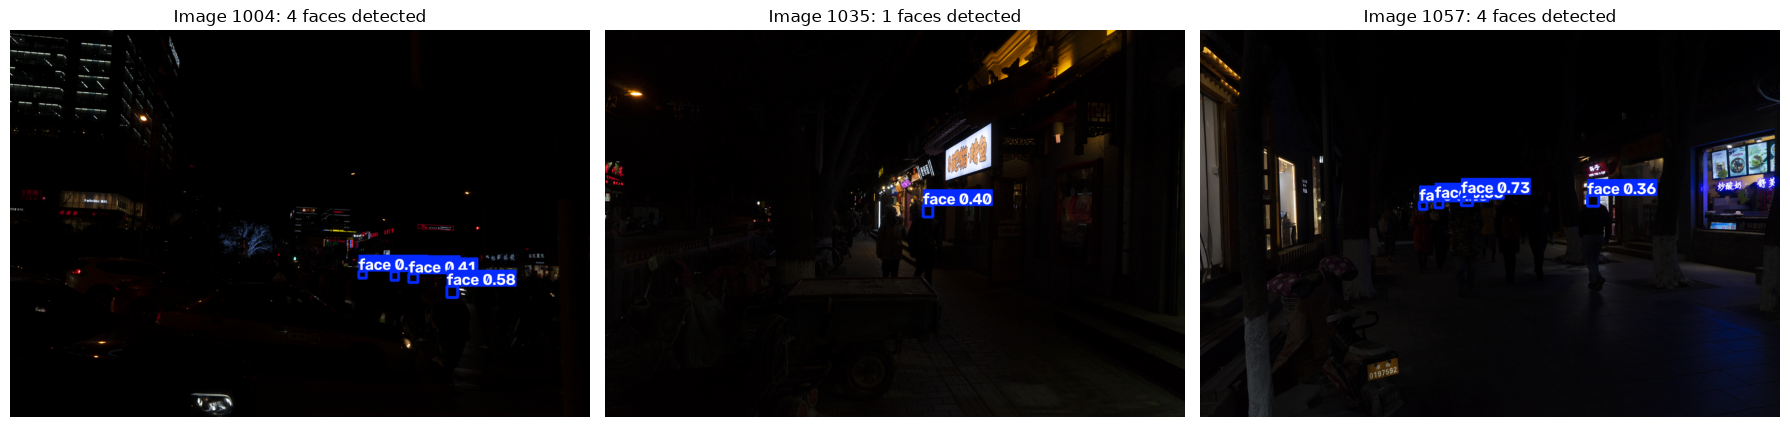

In [3]:
from ultralytics import YOLO

detector = YOLO(str(ROOT / "finetune" / "runs" / "face_finetune_v3" / "weights" / "best.pt"))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, img_id in zip(axes, ["1004", "1035", "1057"]):
    img_path = ROOT / "notebook_demo_data" / "darkface_samples" / f"{img_id}.png"
    result = detector.predict(str(img_path), conf=0.25, classes=[0], verbose=False)[0]
    annotated = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
    ax.imshow(annotated)
    ax.set_title(f"Image {img_id}: {len(result.boxes)} faces detected")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Face Recognition — ArcFace Enrollment & Verification

Enrolls 3 real identities from LFW (2 reference photos each) and tests
recognition against a held-out probe photo of one of them.

In [4]:
from insightface.app import FaceAnalysis

def cosine(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8))

app = FaceAnalysis(providers=["CPUExecutionProvider"], allowed_modules=["detection", "recognition"])
app.prepare(ctx_id=0, det_size=(320, 320))

lfw_dir = ROOT / "notebook_demo_data" / "lfw_samples"
identities = sorted([p for p in lfw_dir.iterdir() if p.is_dir()])
print(f"Enrolling {len(identities)} identities: {[p.name for p in identities]}")

gallery = {}
for p in identities:
    files = sorted(p.glob("*.jpg"))
    img = cv2.imread(str(files[0]))
    faces = app.get(img)
    gallery[p.name] = faces[0].embedding

probe_identity = identities[1]
probe_file = sorted(probe_identity.glob("*.jpg"))[2]
probe_img = cv2.imread(str(probe_file))
probe_emb = app.get(probe_img)[0].embedding

print(f"\nProbe identity (ground truth): {probe_identity.name}\n")
best_name, best_sim = None, -1
for name, emb in gallery.items():
    sim = cosine(probe_emb, emb)
    if sim > best_sim:
        best_sim, best_name = sim, name
    print(f"  similarity to identity '{name}': {sim:.3f}")

print(f"\nPredicted: {best_name} | Correct: {best_name == probe_identity.name}")

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


model ignore: C:\Users\ASUS/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: C:\Users\ASUS/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\ASUS/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: C:\Users\ASUS/.insightface\models\buffalo_l\genderage.onnx genderage


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


find model: C:\Users\ASUS/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (320, 320)
Enrolling 3 identities: ['0', '10', '1002']


C:\Python312\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)



Probe identity (ground truth): 10

  similarity to identity '0': -0.097
  similarity to identity '10': 0.709
  similarity to identity '1002': -0.078

Predicted: 10 | Correct: True


## 4. Ablation Study Results

Real measured results from `ablation_results/` — 600 held-out DARK FACE
images (detection) and 610 LFW identities across 4 lighting conditions
(recognition).

In [5]:
det_df = pd.read_csv(ROOT / "ablation_results" / "ablation_results_detection.csv")
print("Detection ablation (600 DARK FACE images, 4,922 faces):")
display(det_df[["config", "precision", "recall", "f1", "fps"]])

Detection ablation (600 DARK FACE images, 4,922 faces):


,config,precision,recall,f1,fps
0,"Config A: YOLOv5 baseline (stock, person-class)",0.731816,0.535555,0.618489,26.737163
1,"Config B: YOLOv8 baseline (stock, person-class)",0.715661,0.573751,0.636897,25.763776
2,Config C: YOLOv8 fine-tuned face detector,0.878917,0.250711,0.390136,61.876612
3,Config D (proposed): fine-tuned face detector ...,0.400000,0.013409,0.025948,1.105742


In [6]:
rec_df = pd.read_csv(ROOT / "ablation_results" / "ablation_results_recognition.csv")
print("Recognition ablation (610 LFW identities, 1,643 probes):")
pivot = rec_df.pivot(index="lighting", columns="config", values="accuracy")
pivot = pivot.reindex(["bright", "normal", "dim", "dark"])
display(pivot)

Recognition ablation (610 LFW identities, 1,643 probes):


config,ArcFace (InsightFace),ArcFace + TD-FALE-GAN,Baseline (HOG + Euclidean-cosine)
lighting,,,
bright,0.872794,0.754717,0.271759
normal,0.867012,0.882532,0.201461
dim,0.886184,0.911442,0.204808
dark,0.565429,0.525563,0.279976


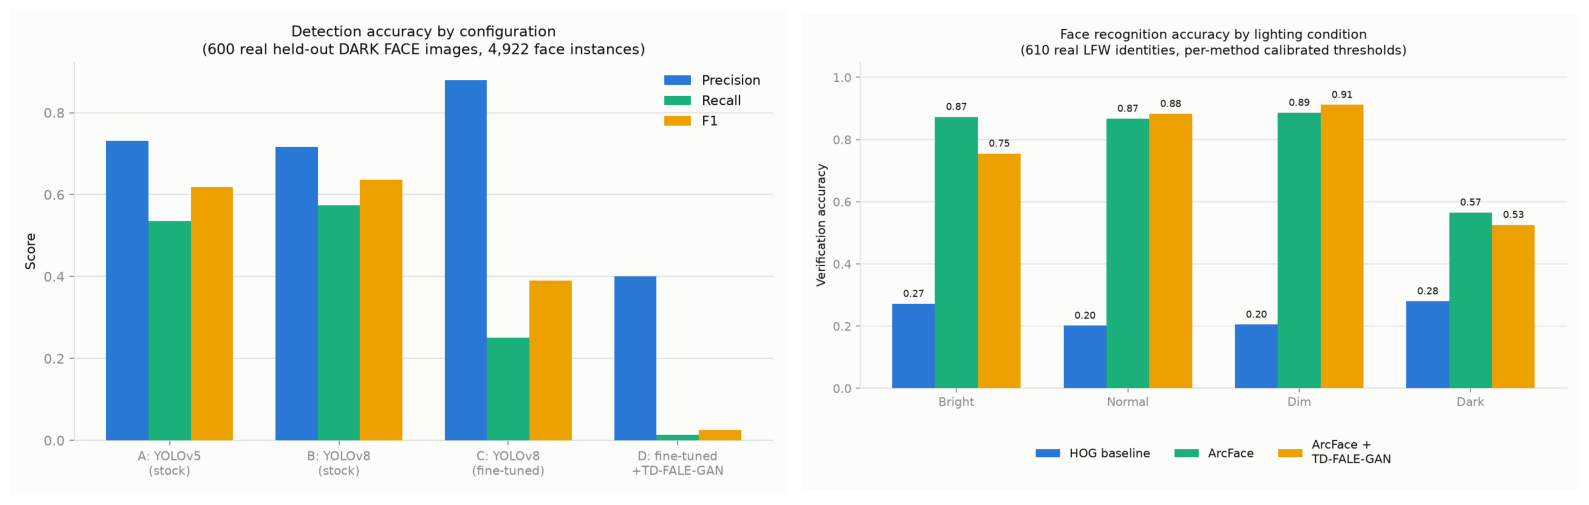

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(mpimg.imread(ROOT / "ablation_results" / "accuracy_comparison.png")); axes[0].axis("off")
axes[1].imshow(mpimg.imread(ROOT / "ablation_results" / "recognition_accuracy_by_lighting.png")); axes[1].axis("off")
plt.tight_layout()
plt.show()

## Key Findings

1. **ArcFace dramatically outperforms the classical HOG baseline**
   (0.87-0.91 vs 0.20-0.28 accuracy) — the largest, most consistent
   effect in this study.
2. **Fine-tuning the detector trades recall for precision and speed**
   (0.879 precision / 61.9 FPS vs 0.716-0.732 precision / ~26 FPS for
   stock models, at the cost of recall).
3. **The enhancement GAN's effect is condition-dependent, not
   universal** — it helps recognition in dim lighting (+0.025 accuracy)
   but hurts in bright and extreme-dark conditions, and hurts detection
   on small/distant faces across the board. This was measured, not
   assumed, and required finding and fixing several real implementation
   bugs along the way (see `paper/main.tex`, Section VI,
   "Reproducibility and integrity").

Full methodology and discussion: see `paper/main.tex` (compile in
Overleaf) or `paper_section_methodology_results.md`.